# EfficientNet Training 

**Project:** GreenThumb AI  
**Model:** EfficientNet-B0  
**Objective:** Train a robust plant disease classifier using GPU acceleration


## Importing libraries

In [1]:
import sys
sys.path.append("../")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from torchvision import models
from tqdm import tqdm

## Setting Device to CUDA

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Loading Data Pipeline

In [3]:
from src.data.datamodule import PlantVillageDataModule

DATA_DIR = "../data/plantvillage dataset/color"

dm = PlantVillageDataModule(
    data_dir=DATA_DIR,
    batch_size=32,        
    img_size=224
)

dm.setup()

In [4]:
# Setting Train and Val Data Loader
train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

num_classes = len(dm.class_to_idx)
print("Number of classes:", num_classes)

Number of classes: 38


## Building EfficientNet Model

In [5]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

In [6]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

In [7]:
# Replace classifier head
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

In [8]:
summary(model) 

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

## Loss, Optimizer, Scheduler

In [9]:
#Setting up thew loss function, the optimizer and the scheduler for the training loop
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=3,
    verbose=True
)

C:\Users\kritr\Downloads\INTERNSHIP\GreenThumb_AI\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Mixed Precision Setup 

In [10]:
scaler = GradScaler()

C:\Users\kritr\AppData\Local\Temp\ipykernel_21812\4292142752.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## Training and Validation Loops

In [11]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

In [12]:
def validate(model, loader):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

### Training Loop

In [13]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [14]:
EPOCHS = 10
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "../models/efficientnet_b0_best.pth")
        print(f"✔ Best model saved at epoch {best_epoch}")

  0%|                                                                                         | 0/1188 [00:00<?, ?it/s]C:\Users\kritr\AppData\Local\Temp\ipykernel_21812\4111617584.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                                                                                       

Epoch [1/10] | Train Loss: 0.4481, Train Acc: 0.8999 | Val Loss: 0.0387, Val Acc: 0.9888
✔ Best model saved at epoch 1


Epoch [2/10] | Train Loss: 0.0523, Train Acc: 0.9851 | Val Loss: 0.0196, Val Acc: 0.9940
✔ Best model saved at epoch 2


Epoch [3/10] | Train Loss: 0.0331, Train Acc: 0.9903 | Val Loss: 0.0215, Val Acc: 0.9925


Epoch [4/10] | Train Loss: 0.0238, Train Acc: 0.9930 | Val Loss: 0.0191, Val Acc: 0.9939
✔ Best model saved at epoch 4


...

Epoch [6/10] | Train Loss: 0.0159, Train Acc: 0.9947 | Val Loss: 0.0135, Val Acc: 0.9962
✔ Best model saved at epoch 6


Epoch [7/10] | Train Loss: 0.0139, Train Acc: 0.9956 | Val Loss: 0.0137, Val Acc: 0.9966


Epoch [8/10] | Train Loss: 0.0130, Train Acc: 0.9959 | Val Loss: 0.0121, Val Acc: 0.9961
✔ Best model saved at epoch 8


Epoch [9/10] | Train Loss: 0.0106, Train Acc: 0.9971 | Val Loss: 0.0155, Val Acc: 0.9956


Epoch [10/10] | Train Loss: 0.0109, Train Acc: 0.9966 | Val Loss: 0.0094, Val Acc: 0.9973
✔ Best model saved at epoch 10


In [19]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 11
        torch.save(model.state_dict(), "../models/efficientnet_b0_best.pth")
        print(f"✔ Best model saved at epoch {best_epoch}")

  0%|                                                                                         | 0/1188 [00:00<?, ?it/s]C:\Users\kritr\AppData\Local\Temp\ipykernel_21812\4111617584.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
                                                                                                                       

Epoch [1/5] | Train Loss: 0.0099, Train Acc: 0.9969 | Val Loss: 0.0138, Val Acc: 0.9962


Epoch [2/5] | Train Loss: 0.0085, Train Acc: 0.9977 | Val Loss: 0.0155, Val Acc: 0.9961


Epoch [3/5] | Train Loss: 0.0081, Train Acc: 0.9974 | Val Loss: 0.0104, Val Acc: 0.9974


Epoch [4/5] | Train Loss: 0.0082, Train Acc: 0.9973 | Val Loss: 0.0096, Val Acc: 0.9977


Epoch [5/5] | Train Loss: 0.0035, Train Acc: 0.9989 | Val Loss: 0.0069, Val Acc: 0.9980
✔ Best model saved at epoch 15


## PLOTS For Research Paper

### Plotting Loss Curves

In [16]:
import matplotlib.pyplot as plt

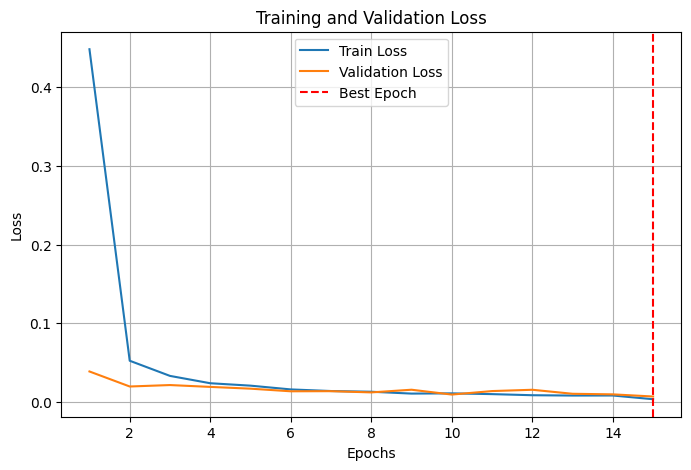

In [20]:
epochs = range(1, EPOCHS + 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.axvline(best_epoch, color="r", linestyle="--", label="Best Epoch")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/plots/train_val_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Plotting Accuracy Curves

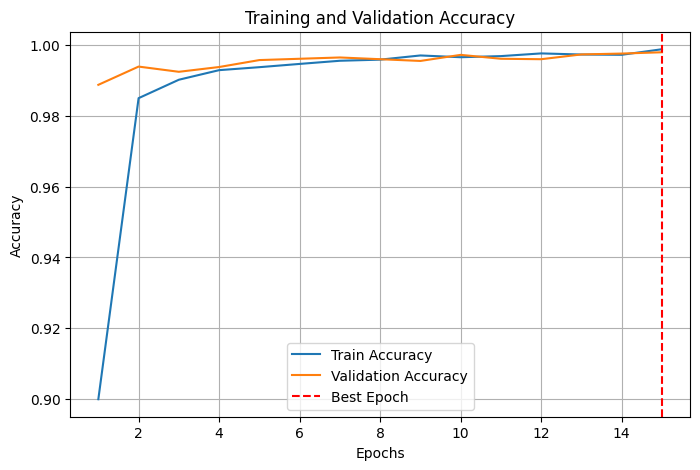

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.axvline(best_epoch, color="r", linestyle="--", label="Best Epoch")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "../outputs/plots/train_val_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### Training Summary

- EfficientNet-B0 successfully fine-tuned on PlantVillage dataset
- Mixed precision training enabled for efficient GPU utilization
- Best model saved based on validation loss
- Model ready for evaluation and integration with RAG pipeline
